# Análisis Exploratorio del Mercado Accionario Chileno

Análisis de precios históricos de tres acciones del IPSA: **COPEC**, **FALABELLA** y **CMPC** (Mayo 2024 – Mayo 2026).

Se calculan retornos totales, retornos diarios, estadística descriptiva y matriz de correlación para caracterizar el comportamiento de cada activo.

In [5]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as mtl
import seaborn as sns

## 1. Carga de datos

Descarga de precios históricos OHLCV via Yahoo Finance. Se aíslan los precios de cierre ajustados.

In [11]:
lista_nombre_acciones = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN"]
datos_brutos_acciones = yf.download(tickers = lista_nombre_acciones, period = "2y")



[*********************100%***********************]  3 of 3 completed


In [12]:
datos_brutos_acciones.head()

Price             Close                                   High               \
Ticker          CMPC.SN     COPEC.SN FALABELLA.SN      CMPC.SN     COPEC.SN   
Date                                                                          
2024-05-13  1901.582764  7248.426758  2592.700928  1903.466525  7279.424306   
2024-05-14  1905.548462  7294.423340  2609.025146  1913.479985  7294.423340   
2024-05-15  1888.693970  7359.418457  2626.310303  1927.360145  7447.711285   
2024-05-16  1893.750244  7269.424805  2631.111572  1903.565528  7449.310474   
2024-05-17  1933.308838  7448.411621  2688.727051  1933.308838  7449.311452   

Price                            Low                                   Open  \
Ticker     FALABELLA.SN      CMPC.SN     COPEC.SN FALABELLA.SN      CMPC.SN   
Date                                                                          
2024-05-13  2640.713908  1840.113456  7059.441704  2587.899630  1901.582764   
2024-05-14  2640.713711  1874.020609  7084.439940  2559.955791  1905.548462   
2024-05-15  2666.545091  1888.693970  7272.625511  2611.906407  1888.693970   
2024-05-16  2640.426044  1883.736721  7180.431846  2609.025599  1893.750244   
2024-05-17  2717.534841  1888.694019  7249.427340  2616.131327  1933.308838   

Price                                 Volume                        
Ticker         COPEC.SN FALABELLA.SN CMPC.SN COPEC.SN FALABELLA.SN  
Date                                                                
2024-05-13  7248.426758  2592.700928  140623    19505       124680  
2024-05-14  7294.423340  2609.025146  713011    86990       425991  
2024-05-15  7359.418457  2626.310303  207898    46812       155806  
2024-05-16  7269.424805  2631.111572  363220   261439       294253  
2024-05-17  7448.411621  2688.727051  744388   184210       310075

In [13]:
precios_cierre = datos_brutos_acciones["Close"]
precios_cierre

Ticker,CMPC.SN,COPEC.SN,FALABELLA.SN
Date,,,
2024-05-13,1901.582764,7248.426758,2592.700928
2024-05-14,1905.548462,7294.423340,2609.025146
2024-05-15,1888.693970,7359.418457,2626.310303
2024-05-16,1893.750244,7269.424805,2631.111572
2024-05-17,1933.308838,7448.411621,2688.727051
...,...,...,...
2026-05-05,1073.171753,6119.875488,5299.899902
2026-05-06,1105.493774,6209.873535,5715.000000
2026-05-07,1128.400024,6199.873535,5880.000000


Variaciones:
COPEC.SN -13.498470640652222%
FALABELLA.SN 116.15297527623889%
CMPC.SN -38.314543946802125%


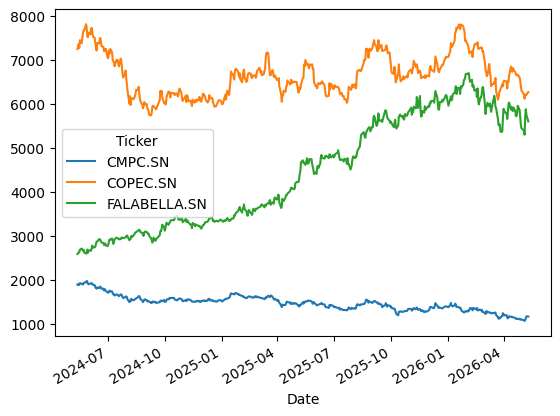

In [14]:
precios_cierre.shape
precios_cierre.plot()
print("Variaciones:")
for i in lista_nombre_acciones:
    print(i, str((precios_cierre[i].iloc[-1] - precios_cierre[i].iloc[0])/precios_cierre[i].iloc[0] * 100) + "%")

<Axes: xlabel='Date'>

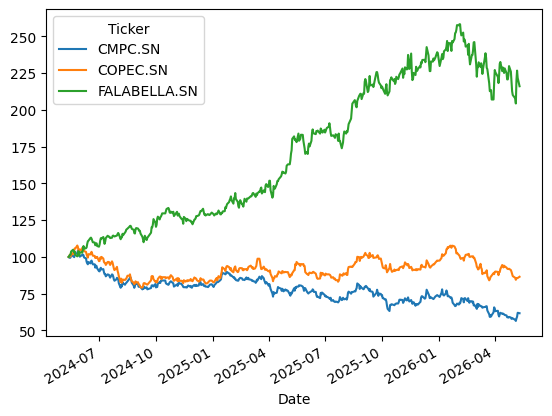

In [15]:
precios_normalizados = precios_cierre/precios_cierre.iloc[0]*100
precios_normalizados.plot()

## 2. Retornos totales y precios normalizados

Se calcula el retorno total de cada acción en el período y se normalizan los precios (base 100) para comparar rendimiento relativo en un mismo gráfico.

In [18]:
dia_ant = None
for i in precios_cierre["COPEC.SN"]:
    if dia_ant == None:
        print("Retornos de COPEC:")
    else:
        print(str((i - dia_ant)/dia_ant*100) + "%")
    dia_ant = i

Retornos de COPEC:
0.6345733159498916%
0.8910247480768263%
-1.222836462815473%
2.462186778393182%
-0.975977536108232%
3.3038301097324494%
0.6561685592905186%
0.0%
1.8383236075770175%
-1.022908522141283%
-2.3424899959209307%
-0.46225455783511454%
1.3892076444855224%
-0.5184028227507631%
1.4511859922562012%
0.5201526859876214%
-0.9055711355344029%
-1.6318490130232872%
-0.4618332829999883%
-1.735963149636013%
-1.1533293176700823%
-0.9883232228441197%
2.3984471795078717%
-0.21121518448552504%
1.078644646072127%
0.6711505297194122%
-2.5320371372825954%
-0.1504773276306127%
-1.3700585883442424%
0.7084334923804056%
-0.44137379935617216%
0.4433305442229152%
-2.881376800671066%
0.12640237386238035%
2.382980037969811%
-0.9628655024566182%
1.4198674606386295%
-1.1034344983904303%
-2.357052212963821%
-0.5570654495754491%
-0.1723638601508629%
-1.3669091285949915%
2.115247760887823%
0.0%
-1.171430470893103%
-0.9251254187212147%
2.5678543037053174%
-1.0526383058205986%
-2.075899899205055%
-1.93200184

In [ ]:
retornos_diarios = precios_cierre.pct_change()
retornos_diarios

Ticker,CMPC.SN,COPEC.SN,FALABELLA.SN
Date,,,
2024-05-13,NaN,NaN,NaN
2024-05-14,0.002085,0.006346,0.006296
2024-05-15,-0.008845,0.008910,0.006625
2024-05-16,0.002677,-0.012228,0.001828
2024-05-17,0.020889,0.024622,0.021898
...,...,...,...
2026-05-05,-0.013309,-0.015840,-0.016716
2026-05-06,0.030118,0.014706,0.078322
2026-05-07,0.020720,-0.001610,0.028871


## 3. Retornos diarios y estadística descriptiva

Los retornos diarios se calculan con `pct_change()`. Se reportan: retorno promedio diario, volatilidad (desviación estándar) y Sharpe simplificado (retorno/volatilidad, sin tasa libre de riesgo).

In [31]:
print(retornos_diarios.mean())
print(retornos_diarios.std())

print("Ratio de Sharpe:")
for i in lista_nombre_acciones:
    print(i + ":", retornos_diarios[i].mean()/retornos_diarios[i].std())

Ticker
CMPC.SN        -0.000834
COPEC.SN       -0.000182
FALABELLA.SN    0.001706
dtype: float64
Ticker
CMPC.SN         0.017111
COPEC.SN        0.015001
FALABELLA.SN    0.016856
dtype: float64
Ratio de Sharpe:
COPEC.SN: -0.012125673603951455
FALABELLA.SN: 0.10121877562697591
CMPC.SN: -0.04872491479811509


In [32]:
retornos_diarios.mean()/retornos_diarios.std()

Ticker
CMPC.SN        -0.048725
COPEC.SN       -0.012126
FALABELLA.SN    0.101219
dtype: float64

## 4. Matriz de correlación

La correlación entre retornos diarios mide qué tan relacionados están los movimientos de precio entre pares de activos. Valores cercanos a 1 indican que se mueven juntos; cercanos a 0, independencia.

Ticker         CMPC.SN  COPEC.SN  FALABELLA.SN
Ticker                                        
CMPC.SN       1.000000  0.550003      0.378684
COPEC.SN      0.550003  1.000000      0.346281
FALABELLA.SN  0.378684  0.346281      1.000000


<Axes: xlabel='Ticker', ylabel='Ticker'>

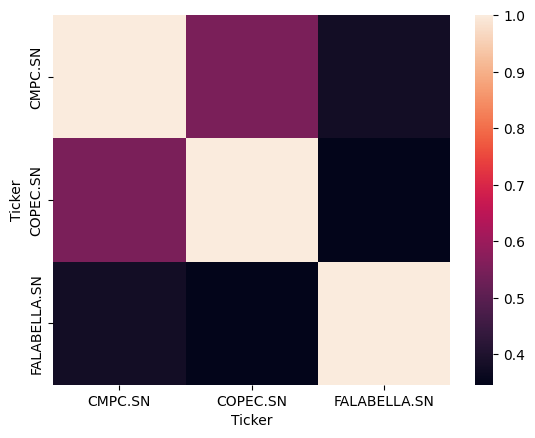

In [41]:
print(retornos_diarios.corr())
sns.heatmap(retornos_diarios.corr())